#MY PROJECT

**TITLE** : Patient Review Sentiment Analysis (Healthcare)

## Problem Statement
To build a machine learning model that automatically classifies drug reviews into positive or negative sentiment using NLP techniques, helping analyze patient feedback efficiently.


DATASET : KAGGLE DRUG REVIEWS DATASET

MODEL : LOGISTIC REGRESSION

##IMPORTING LIBRARIES

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re

##READING DATASET & EDA


In [7]:
df = pd.read_csv("/content/drugsComTest_raw.csv")
print(df.head())
print(df.info())

   uniqueID         drugName                     condition  \
0    163740      Mirtazapine                    Depression   
1    206473       Mesalamine  Crohn's Disease, Maintenance   
2    159672          Bactrim       Urinary Tract Infection   
3     39293         Contrave                   Weight Loss   
4     97768  Cyclafem 1 / 35                 Birth Control   

                                              review  rating       date  \
0  "I&#039;ve tried a few antidepressants over th...      10  28-Feb-12   
1  "My son has Crohn&#039;s disease and has done ...       8  17-May-09   
2                      "Quick reduction of symptoms"       9  29-Sep-17   
3  "Contrave combines drugs that were used for al...       9   5-Mar-17   
4  "I have been on this birth control for one cyc...       9  22-Oct-15   

   usefulCount  
0           22  
1           17  
2            3  
3           35  
4            4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53766 entries, 0 to 5376

##CREATING RESULT COLUMN BASED ON CONDITION

In [8]:

df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 5 else 0)
df['sentiment'].value_counts()

,count
sentiment,
1,37559
0,16207


##DATA PREPROCESSING

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

##SPLIT DATA

In [10]:
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##TF-IDF VECTORIZATION

In [11]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

##TRAINING AND PREDICTING
#Logistic Regression

In [17]:
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = lr_balanced.predict(X_test_tfidf)

##MODEL EVALUATION

Balanced Model Accuracy: 0.831


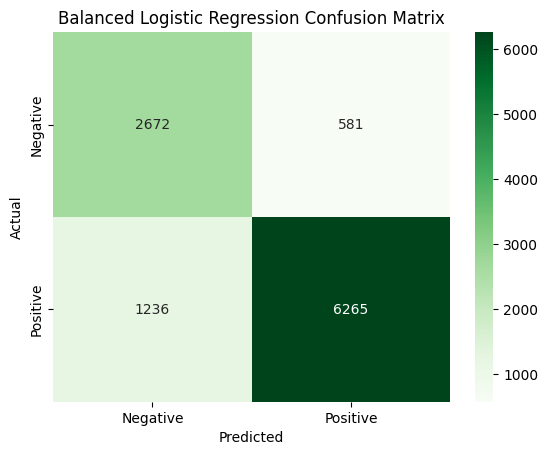

              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3253
           1       0.92      0.84      0.87      7501

    accuracy                           0.83     10754
   macro avg       0.80      0.83      0.81     10754
weighted avg       0.85      0.83      0.83     10754



In [13]:
acc_balanced = accuracy_score(y_test, y_pred_balanced)
print("Balanced Model Accuracy:", round(acc_balanced, 4))

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_balanced))

##Real-Time Sentiment Prediction

In [14]:
def predict_sentiment(review, model, vectorizer):

    clean_review = clean_text(review)

    review_vec = vectorizer.transform([clean_review])

    prob = model.predict_proba(review_vec)[0][1]
    pred = model.predict(review_vec)[0]

    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Probability of Positive: {prob:.2f}\n")

    return pred, prob

##Model Testing with Sample and User Input

In [16]:
example_reviews = [
    "It has no side effect, I take it daily and feel great!",
    "This drug made me feel sick and tired, very bad experience.",
    "Not sure if it works, but no side effects so far."
]

for review in example_reviews:
    predict_sentiment(review, lr_balanced, tfidf)

user_review = input("Enter a drug review: ")
predict_sentiment(user_review, lr_balanced, tfidf)

Review: It has no side effect, I take it daily and feel great!
Predicted Sentiment: Positive
Probability of Positive: 0.99

Review: This drug made me feel sick and tired, very bad experience.
Predicted Sentiment: Negative
Probability of Positive: 0.04

Review: Not sure if it works, but no side effects so far.
Predicted Sentiment: Positive
Probability of Positive: 0.90

Enter a drug review: NOT GOOD
Review: NOT GOOD
Predicted Sentiment: Negative
Probability of Positive: 0.14



(np.int64(0), np.float64(0.14195202292679843))